In [11]:
data = '''
Base tabPFN acc:  0.9692982456140351
RFR (n_estim=1) base acc:  0.9078947368421053
RFR (n_estim=1) aug acc:  0.9035087719298246
RFR (n_estim=2) base acc:  0.875
RFR (n_estim=2) aug acc:  0.9298245614035088
RFR (n_estim=3) base acc:  0.9517543859649122
RFR (n_estim=3) aug acc:  0.9035087719298246
RFR (n_estim=5) base acc:  0.918859649122807
RFR (n_estim=5) aug acc:  0.9385964912280702
RFR (n_estim=10) base acc:  0.9407894736842105
RFR (n_estim=10) aug acc:  0.9495614035087719
RFR (n_estim=100) base acc:  0.9429824561403509
RFR (n_estim=100) aug acc:  0.9407894736842105
MLP (hidden_l=(8,)) base acc:  0.36403508771929827
MLP (hidden_l=(8,)) aug acc:  0.9210526315789473
MLP (hidden_l=(32,)) base acc:  0.37280701754385964
MLP (hidden_l=(32,)) aug acc:  0.9276315789473685
MLP (hidden_l=(128,)) base acc:  0.3793859649122807
MLP (hidden_l=(128,)) aug acc:  0.918859649122807
MLP (hidden_l=(16, 16)) base acc:  0.5964912280701754
MLP (hidden_l=(16, 16)) aug acc:  0.9232456140350878

'''

In [12]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

lines = data.strip().split('\n')

parsed_data = []
for line in lines:
    match = re.match(r'(Base tabPFN|RFR \(n_estim=\d+\)|MLP \(hidden_l=.*?\)) (base|aug) acc:\s*([0-9.]+)', line)
    if match:
        model_info = match.group(1)
        acc_type = match.group(2)
        accuracy = float(match.group(3))
        model_name_match = re.match(r'^(Base tabPFN|RFR|MLP) (.*)', model_info)
        if model_name_match:
            model = model_name_match.group(1)
            parameters = model_name_match.group(2).strip()
        else:
            model = model_info
            parameters = ''

        parsed_data.append({
            'Model': model,
            'Parameters': parameters,
            'Accuracy Type': acc_type,
            'Accuracy': accuracy
        })

df = pd.DataFrame(parsed_data)
df['Model_Config'] = df.apply(lambda row: f"{row['Model']} {row['Parameters']}" if row['Parameters'] else row['Model'], axis=1)
display(df.head())

,Model,Parameters,Accuracy Type,Accuracy,Model_Config
0,RFR,(n_estim=1),base,0.907895,RFR (n_estim=1)
1,RFR,(n_estim=1),aug,0.903509,RFR (n_estim=1)
2,RFR,(n_estim=2),base,0.875000,RFR (n_estim=2)
3,RFR,(n_estim=2),aug,0.929825,RFR (n_estim=2)
4,RFR,(n_estim=3),base,0.951754,RFR (n_estim=3)


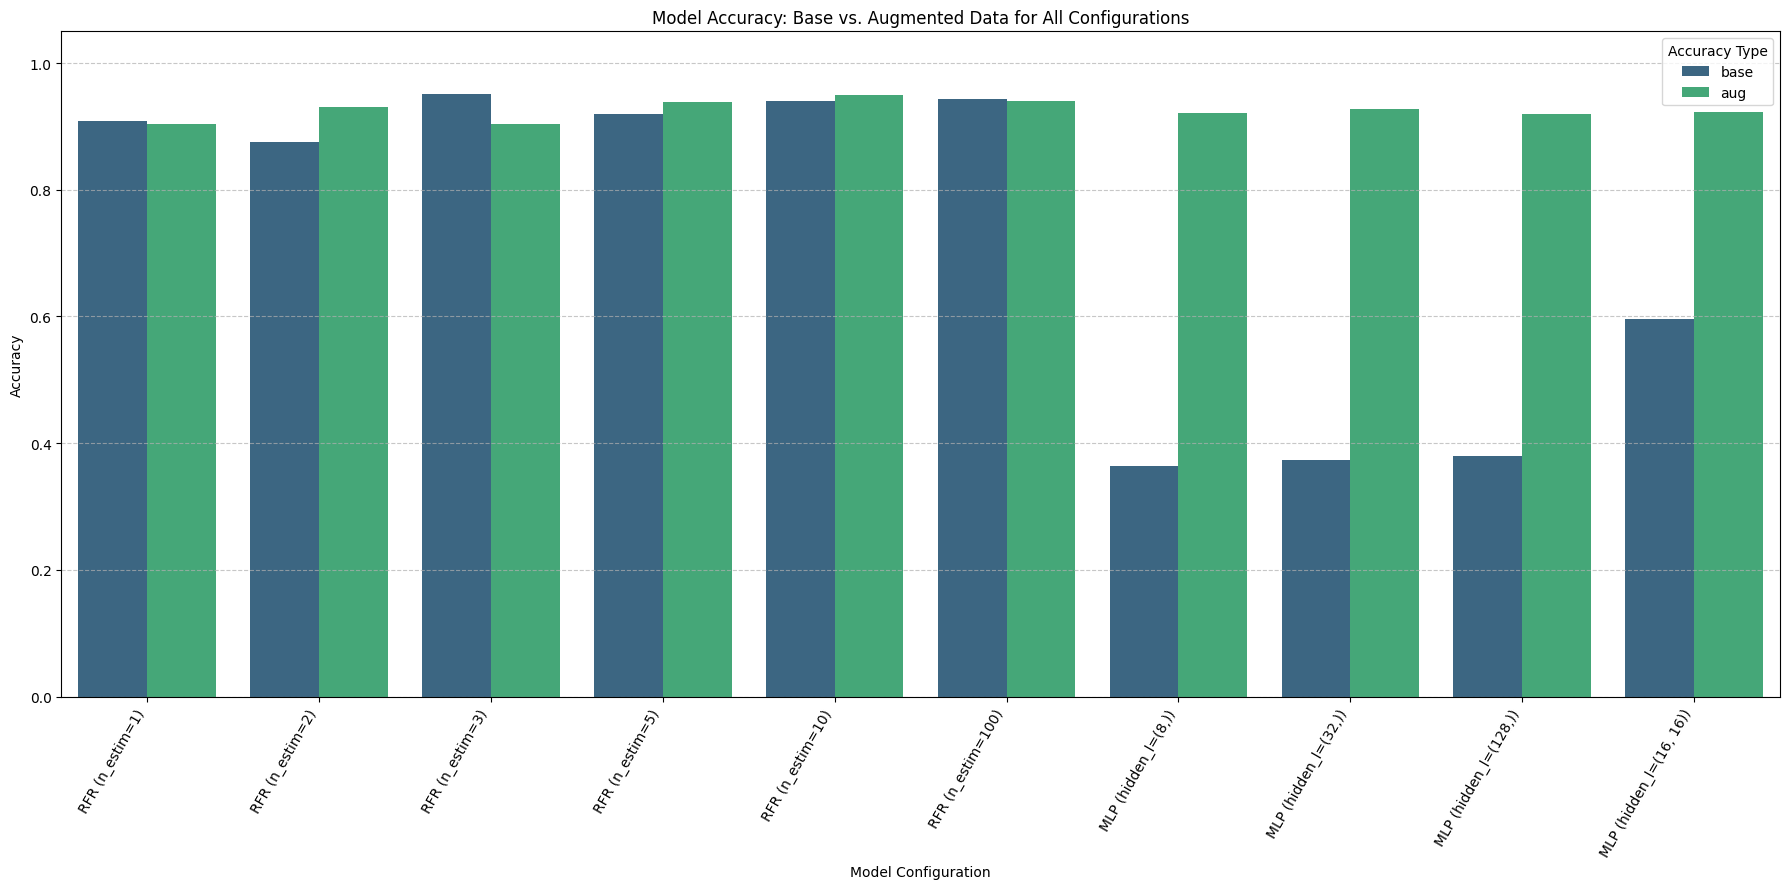

In [13]:
plt.figure(figsize=(18, 9))

sns.barplot(x='Model_Config', y='Accuracy', hue='Accuracy Type', data=df, palette='viridis', errorbar=None)

plt.title('Model Accuracy: Base vs. Augmented Data for All Configurations')
plt.xlabel('Model Configuration')
plt.ylabel('Accuracy')
plt.xticks(rotation=60, ha='right')
plt.ylim(0, 1.05)
plt.legend(title='Accuracy Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()